In [3]:
# from google.colab import drivea
# drive.mount('/content/drive')

In [4]:
import os
os.chdir("/content")

In [7]:
# !rm -rf "/content/vlm-safety-reasoning"

In [8]:
import os
import subprocess
import shutil

DRIVE_ROOT = "/content/drive/MyDrive/vlm-finetuning-project1"
REPO_DIR = "vlm-safety-reasoning"
ENV_PATH = f"{DRIVE_ROOT}/secrets/.env"

def load_secrets(env_path: str) -> dict:
    """Read a .env file and export its values into os.environ."""
    if not os.path.exists(env_path):
        raise FileNotFoundError(f"Secrets file not found at: {env_path}")

    secrets = {}
    with open(env_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            key, value = line.split("=", 1)
            secrets[key] = value.strip(" \"'\r")
            os.environ[key] = secrets[key]
    return secrets


print(">>> Loading secrets...")
secrets = load_secrets(ENV_PATH)
required_keys = ["GIT_EMAIL", "GIT_NAME", "GITHUB_USERNAME", "GITHUB_TOKEN", "HF_TOKEN"]
missing = [k for k in required_keys if k not in secrets]
if missing:
    raise KeyError(f"Missing required secrets: {missing}")
print(">>> Secrets loaded successfully.")

print(">>> Configuring Git identity...")
subprocess.run(["git", "config", "--global", "user.email", secrets["GIT_EMAIL"]], check=True)
subprocess.run(["git", "config", "--global", "user.name", secrets["GIT_NAME"]], check=True)

AUTH_REPO_URL = (
    f"https://{secrets['GITHUB_USERNAME']}:{secrets['GITHUB_TOKEN']}"
    f"@github.com/epmresearch/vlm-safety-reasoning.git"
)

if os.path.exists(REPO_DIR):
    print(">>> Repo already present, pulling latest...")
    os.chdir(REPO_DIR)
    subprocess.run(["git", "remote", "set-url", "origin", AUTH_REPO_URL], check=True)
    subprocess.run(["git", "pull", "origin", "main"], check=True)
else:
    print(">>> Cloning repo...")
    subprocess.run(["git", "clone", AUTH_REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

print(f">>> Working directory: {os.getcwd()}")

print(">>> Copying .env into local workspace...")
shutil.copy(ENV_PATH, ".env")

print(">>> Installing requirements...")
subprocess.run(["pip", "install", "-q", "-r", "requirements.txt"], check=True)
print(">>> Setup complete.")

>>> Loading secrets...
>>> Secrets loaded successfully.
>>> Configuring Git identity...
>>> Cloning repo...
>>> Working directory: /content/vlm-safety-reasoning
>>> Copying .env into local workspace...
>>> Installing requirements...
>>> Setup complete.


In [9]:
import os
import json
import time
from pathlib import Path
from huggingface_hub import login
from core.config import load_config
from core.io import get_drive_path, ensure_dir
from core.run_manifest import save_run_manifest
from core.logging import get_logger
from data.loader import load_processed_dataset
from data.preprocessor import build_ground_truth_dict
from models.model_loader import load_model_for_inference
from models.inference import run_inference_batched

In [10]:
logger = get_logger("base_inference_test")
login(token=os.environ["HF_TOKEN"])
base_config = load_config(task="unified")
print("=== CURRENT CONFIGURATION STATE ===")
print(json.dumps(base_config, indent=2))
print("========================================\n")
print("If want to change any of these permanently, edit the YAML files.")
print("If want to override them just for this run, override into the run_config dictionary!")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


=== CURRENT CONFIGURATION STATE ===
{
  "drive_root": "/content/drive/MyDrive/vlm-finetuning-project1",
  "hf_org": "nabeelshan",
  "wandb_project": "vlm-safety-project1",
  "wandb_entity": "nabeel-shan-research",
  "seed": 42,
  "dataset": {
    "hf_repo": "LouisChen15/ConstructionSite",
    "raw_cache_subdir": "datasets/raw",
    "cleaned_subdir": "datasets/raw_cleaned",
    "processed_subdir": "datasets/processed"
  },
  "paths": {
    "checkpoints_subdir": "checkpoints",
    "results_subdir": "results",
    "figures_subdir": "figures",
    "logs_subdir": "logs",
    "secrets_subdir": "secrets"
  },
  "active_tier": "2b",
  "models": {
    "2b": {
      "hf_path": "unsloth/Qwen3-VL-2B-Instruct",
      "short_name": "qwen3vl-2b",
      "size_label": "Small (2B)",
      "per_device_train_batch_size": 4,
      "gradient_accumulation_steps": 4
    },
    "4b": {
      "hf_path": "unsloth/Qwen3-VL-4B-Instruct",
      "short_name": "qwen3vl-4b",
      "size_label": "Mid (4B)",
      "per_

In [11]:
MODEL_TIER = "2b"
N_SAMPLES = 32
BATCH_SIZE = 32

DRIVE_RESULTS_DIR = get_drive_path("results", "testing", f"baseline_{MODEL_TIER}")
ensure_dir(DRIVE_RESULTS_DIR)

JSONL_OUTPUT_PATH = str(DRIVE_RESULTS_DIR / "predictions.jsonl")
METRICS_OUTPUT_PATH = str(DRIVE_RESULTS_DIR / "metrics.json")

run_config = {
    "experiment": f"baseline_testing_inference_{N_SAMPLES}_samples",
    "model_tier": MODEL_TIER,
    "batch_size": BATCH_SIZE,
    "max_new_tokens": base_config.get("max_new_tokens", 1000),
    "notes": "Colab batched auto-resume run",
    "full_yaml_state": base_config,
}
save_run_manifest(str(DRIVE_RESULTS_DIR), run_config)
print("Manifest saved. Results dir:", DRIVE_RESULTS_DIR)

2026-07-17 10:24:42 | INFO     | core.run_manifest:save_run_manifest:38 - Run manifest saved to /content/drive/MyDrive/vlm-finetuning-project1/results/testing/baseline_2b/run_manifest.json
Manifest saved. Results dir: /content/drive/MyDrive/vlm-finetuning-project1/results/testing/baseline_2b


In [12]:
full_ds = load_processed_dataset()
mini_test = full_ds["test"].select(range(N_SAMPLES))
print(mini_test)

2026-07-17 10:24:42 | INFO     | data.loader:load_processed_dataset:183 - Loading fully processed dataset from disk: /content/drive/MyDrive/vlm-finetuning-project1/datasets/processed
2026-07-17 10:25:14 | INFO     | data.loader:load_processed_dataset:187 - Loaded processed 'train' split: 6308 samples
2026-07-17 10:25:14 | INFO     | data.loader:load_processed_dataset:187 - Loaded processed 'val' split: 701 samples
2026-07-17 10:25:14 | INFO     | data.loader:load_processed_dataset:187 - Loaded processed 'test' split: 3004 samples
Dataset({
    features: ['image', 'image_id', 'image_caption', 'illumination', 'camera_distance', 'view', 'quality_of_info', 'rule_1_violation', 'rule_2_violation', 'rule_3_violation', 'rule_4_violation', 'excavator', 'rebar', 'worker_with_white_hard_hat'],
    num_rows: 32
})


In [13]:
model, tokenizer, info = load_model_for_inference(tier=MODEL_TIER)
print("Loaded model:", info["hf_path"])

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
2026-07-17 10:25:42 | INFO     | models.model_loader:load_model_for_inference:164 - Loading model for inference: unsloth/Qwen3-VL-2B-Instruct with max_seq_length=8192
==((====))==  Unsloth 2026.7.3: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

Loaded model: unsloth/Qwen3-VL-2B-Instruct


In [14]:
print(f"Starting batch inference on {len(mini_test)} samples...")
t0 = time.time()

batch_results = run_inference_batched(
    model=model,
    tokenizer=tokenizer,
    dataset=mini_test,
    batch_size=BATCH_SIZE,
    max_new_tokens=base_config.get("max_new_tokens", 1000),
    output_path=JSONL_OUTPUT_PATH,
)

elapsed = time.time() - t0
n_errors = sum(1 for r in batch_results if "error" in r)
print(f"\nDone in {elapsed:.1f}s")
print(f"Successful outputs: {len(batch_results) - n_errors} | Errors: {n_errors}")

Starting batch inference on 32 samples...


Batched Inference: 100%|██████████| 1/1 [02:41<00:00, 161.90s/it]

2026-07-17 10:29:18 | INFO     | models.inference:run_inference_batched:319 - Batched inference complete: 32 new samples processed.

Done in 161.9s
Successful outputs: 32 | Errors: 0


In [15]:
raw_predictions = [res["raw_output"] for res in batch_results]

for idx, raw_str in enumerate(raw_predictions[10:15]):
    print(f"\n============= RAW OUTPUT SAMPLE {idx} =============")
    print(raw_str)


============= RAW OUTPUT SAMPLE 0 =============
```json
{
  "caption": "A group of workers wearing red hard hats and work clothes are constructing a metal grate structure on a dirt site near a gate with concrete pillars. The area is surrounded by trees and has some blue plastic containers nearby. Workers appear to be assembling or positioning components of the structure.",
  "rule_1_violation": {
    "bounding_box": [
      [287, 375, 376, 609],
      [438, 387, 480, 511],
      [500, 387, 550, 540],
      [758, 415, 832, 660]
    ],
    "reason": "Workers are not using appropriate protective gear such as safety vests, gloves, or other required personal protective equipment."
  },
  "rule_2_violation": null,
  "rule_3_violation": null,
  "rule_4_violation": null,
  "excavator": [],
  "rebar": [],
  "worker_with_white_hard_hat": []
}
```

============= RAW OUTPUT SAMPLE 1 =============
```json
{
  "caption": "The image shows two workers carrying long metal panels on a blue truck, with 

In [16]:
def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    return records

batch_results = load_jsonl(JSONL_OUTPUT_PATH)
print(f"Loaded {len(batch_results)} records from {JSONL_OUTPUT_PATH}")

raw_predictions = [res["raw_output"] for res in batch_results]
references = [build_ground_truth_dict(res["sample"]) for res in batch_results]
metadata_list = [res["sample"] for res in batch_results]

Loaded 32 records from /content/drive/MyDrive/vlm-finetuning-project1/results/testing/baseline_2b/predictions.jsonl


In [17]:
from evaluation.metrics_structural import compute_structural_metrics
from evaluation.output_parser import parse_model_output

struct_metrics = compute_structural_metrics(raw_predictions)
print("=== STRUCTURAL METRICS ===")
print(json.dumps(struct_metrics, indent=2))

parsed_preds = [parse_model_output(raw_str) for raw_str in raw_predictions]
safe_preds = [p if p is not None else {} for p in parsed_preds]

n_parsed = sum(1 for p in parsed_preds if p is not None)
print(f"\nSuccessfully parsed {n_parsed} / {len(raw_predictions)} outputs.")

if n_parsed < len(raw_predictions):
    print("\n--- Unparseable samples ---")
    for i, p in enumerate(parsed_preds):
        if p is None:
            print(f"[{i}] image_id={batch_results[i]['sample'].get('image_id')}")

=== STRUCTURAL METRICS ===
{
  "json_validity_rate": 0.9375,
  "schema_adherence_rate": 0.40625,
  "valid_json_count": 30,
  "valid_schema_count": 13,
  "total_samples": 32
}

Successfully parsed 30 / 32 outputs.

--- Unparseable samples ---
[1] image_id=0000002
[17] image_id=0000030


In [18]:
from evaluation.metrics_grounding import compute_grounding_metrics

grounding_metrics = compute_grounding_metrics(safe_preds, references)

print("=== GROUNDING METRICS (mean scores) ===")
for k, v in grounding_metrics.items():
    if "mean" in k:
        print(f"{k.ljust(35)}: {v:.4f}")

grounding_metrics

=== GROUNDING METRICS (mean scores) ===
grounding_iou_total_macro_mean     : 0.6594
grounding_iou_total_micro_mean     : 0.1283
grounding_iou_exist_macro_mean     : 0.2524
grounding_iou_exist_micro_mean     : 0.2602


{'grounding_iou_total_macro_excavator': 0.7769764230354761,
 'grounding_iou_total_micro_excavator': 0.3835484229014534,
 'grounding_iou_exist_macro_excavator': 0.4052704614279364,
 'grounding_iou_exist_micro_excavator': 0.3835484229014534,
 'grounding_tn_count_excavator': 20,
 'grounding_fp_count_excavator': 0,
 'grounding_fn_count_excavator': 3,
 'grounding_exist_n_excavator': 12,
 'grounding_iou_total_macro_rebar': 0.6074231150793651,
 'grounding_iou_total_micro_rebar': 0.0042214522980229445,
 'grounding_iou_exist_macro_rebar': 0.06250566893424034,
 'grounding_iou_exist_micro_rebar': 0.017672231868572197,
 'grounding_tn_count_rebar': 19,
 'grounding_fp_count_rebar': 6,
 'grounding_fn_count_rebar': 4,
 'grounding_exist_n_rebar': 7,
 'grounding_iou_total_macro_worker_with_white_hard_hat': 0.59375,
 'grounding_iou_total_micro_worker_with_white_hard_hat': 0.0,
 'grounding_iou_exist_macro_worker_with_white_hard_hat': 0.0,
 'grounding_iou_exist_micro_worker_with_white_hard_hat': 0.0,
 'gro

In [19]:
from evaluation.metrics_violations import compute_violation_metrics

violation_metrics = compute_violation_metrics(safe_preds, references)

print("=== VIOLATION METRICS ===")
print(f"Macro Precision : {violation_metrics.get('violation_macro_precision', 0.0):.4f}")
print(f"Macro Recall    : {violation_metrics.get('violation_macro_recall', 0.0):.4f}")
print(f"Macro F1        : {violation_metrics.get('violation_macro_f1', 0.0):.4f}")
print(f"Grounding IoU   : {violation_metrics.get('violation_grounding_iou', 0.0):.4f}")

print("\nPer-Rule Breakdown:")
for k, v in violation_metrics.items():
    if "violation_rule" in k:
        print(f"{k.ljust(35)}: {v:.4f}")

violation_metrics

=== VIOLATION METRICS ===
Macro Precision : 0.2000
Macro Recall    : 0.6667
Macro F1        : 0.3077
Grounding IoU   : 0.2093

Per-Rule Breakdown:
violation_rule_1_precision         : 0.2000
violation_rule_1_recall            : 1.0000
violation_rule_1_f1                : 0.3333
violation_rule_2_precision         : 0.0000
violation_rule_2_recall            : 0.0000
violation_rule_2_f1                : 0.0000
violation_rule_3_precision         : 0.0000
violation_rule_3_recall            : 0.0000
violation_rule_3_f1                : 0.0000
violation_rule_4_precision         : 0.0000
violation_rule_4_recall            : 0.0000
violation_rule_4_f1                : 0.0000
violation_rule_0_precision         : 1.0000
violation_rule_0_recall            : 0.0800
violation_rule_0_f1                : 0.1481


{'violation_macro_precision': 0.2,
 'violation_macro_recall': 0.6666666666666666,
 'violation_macro_f1': 0.30769230769230765,
 'violation_rule_1_precision': 0.2,
 'violation_rule_1_recall': 1.0,
 'violation_rule_1_f1': 0.33333333333333337,
 'violation_rule_2_precision': 0.0,
 'violation_rule_2_recall': 0.0,
 'violation_rule_2_f1': 0.0,
 'violation_rule_3_precision': 0.0,
 'violation_rule_3_recall': 0.0,
 'violation_rule_3_f1': 0.0,
 'violation_rule_4_precision': 0.0,
 'violation_rule_4_recall': 0.0,
 'violation_rule_4_f1': 0.0,
 'violation_rule_0_precision': 1.0,
 'violation_rule_0_recall': 0.08,
 'violation_rule_0_f1': 0.14814814814814814,
 'violation_iou_rule_1': 0.2092822727370519,
 'violation_iou_rule_2': 0.0,
 'violation_iou_rule_3': 0.0,
 'violation_iou_rule_4': 0.0,
 'violation_grounding_iou': 0.2092822727370519}

In [20]:
from evaluation.metrics_reasoning import batch_score_reasoning

reasoning_metrics = batch_score_reasoning(safe_preds, references)

print("=== REASONING METRICS (macro) ===")
for k, v in reasoning_metrics.items():
    if "macro" in k:
        print(f"{k.ljust(35)}: {v:.4f}")

reasoning_metrics

Reasoning Eval: 100%|██████████| 32/32 [00:00<00:00, 135573.46it/s]

2026-07-17 10:31:14 | INFO     | evaluation.metrics_reasoning:batch_score_reasoning:59 - Computing global reasoning metrics over 6 valid reasons...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

2026-07-17 10:31:29 | INFO     | evaluation.metrics_reasoning:batch_score_reasoning:71 - Computing reasoning metrics for rule_1 over 6 valid reasons...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

=== REASONING METRICS (macro) ===
reasoning_macro_bertscore_precision: 0.2630
reasoning_macro_bertscore_recall   : 0.4807
reasoning_macro_bertscore_f1       : 0.3702
reasoning_macro_meteor             : 0.2854
reasoning_macro_cider              : 0.1499


{'reasoning_macro_bertscore_precision': 0.2630453407764435,
 'reasoning_macro_bertscore_recall': 0.48067232966423035,
 'reasoning_macro_bertscore_f1': 0.3701796531677246,
 'reasoning_macro_meteor': 0.2854317816550735,
 'reasoning_macro_cider': 0.14987767913480218,
 'reasoning_rule_1_bertscore_precision': 0.2630453407764435,
 'reasoning_rule_1_bertscore_recall': 0.48067232966423035,
 'reasoning_rule_1_bertscore_f1': 0.3701796531677246,
 'reasoning_rule_1_meteor': 0.2854317816550735,
 'reasoning_rule_1_cider': 0.14987767913480218,
 'reasoning_rule_2_bertscore_f1': 0.0,
 'reasoning_rule_2_meteor': 0.0,
 'reasoning_rule_2_cider': 0.0,
 'reasoning_rule_3_bertscore_f1': 0.0,
 'reasoning_rule_3_meteor': 0.0,
 'reasoning_rule_3_cider': 0.0,
 'reasoning_rule_4_bertscore_f1': 0.0,
 'reasoning_rule_4_meteor': 0.0,
 'reasoning_rule_4_cider': 0.0}

In [21]:
from evaluation.evaluator import run_full_evaluation

print("Running unified evaluation wrapper...")
final_eval_payload = run_full_evaluation(raw_predictions, references)

print(f"\nWrapper executed successfully! Total metrics tracked: {len(final_eval_payload['metrics'])}")

with open(METRICS_OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(final_eval_payload["metrics"], f, indent=2, ensure_ascii=False)

failures_path = str(DRIVE_RESULTS_DIR / "json_schema_failures.jsonl")
with open(failures_path, "w", encoding="utf-8") as f:
    for failure in final_eval_payload.get("failures", []):
        f.write(json.dumps(failure) + "\n")

print(f"Metrics saved to: {METRICS_OUTPUT_PATH}")
print(f"Schema failures logged to: {failures_path} ({len(final_eval_payload.get('failures', []))} failures)")

Running unified evaluation wrapper...
2026-07-17 10:31:38 | INFO     | evaluation.evaluator:run_full_evaluation:24 - Starting full evaluation pipeline...
2026-07-17 10:31:38 | INFO     | evaluation.evaluator:run_full_evaluation:71 - Computing captioning metrics...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

2026-07-17 10:31:41 | INFO     | evaluation.evaluator:run_full_evaluation:75 - Computing grounding metrics...
2026-07-17 10:31:41 | INFO     | evaluation.evaluator:run_full_evaluation:79 - Computing safety violation metrics...
2026-07-17 10:31:41 | INFO     | evaluation.evaluator:run_full_evaluation:83 - Computing reasoning metrics (Captioning Suite)...


Reasoning Eval: 100%|██████████| 32/32 [00:00<00:00, 162688.16it/s]

2026-07-17 10:31:41 | INFO     | evaluation.metrics_reasoning:batch_score_reasoning:59 - Computing global reasoning metrics over 3 valid reasons...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

2026-07-17 10:31:44 | INFO     | evaluation.metrics_reasoning:batch_score_reasoning:71 - Computing reasoning metrics for rule_1 over 3 valid reasons...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

2026-07-17 10:31:47 | INFO     | evaluation.evaluator:run_full_evaluation:94 - Evaluation complete. 19 schema failures logged.

Wrapper executed successfully! Total metrics tracked: 80
Metrics saved to: /content/drive/MyDrive/vlm-finetuning-project1/results/testing/baseline_2b/metrics.json
Schema failures logged to: /content/drive/MyDrive/vlm-finetuning-project1/results/testing/baseline_2b/json_schema_failures.jsonl (19 failures)


In [23]:
def sanitize_boxes(box_data):
    if not box_data or not isinstance(box_data, list):
        return []
    if len(box_data) == 4 and isinstance(box_data[0], (int, float)):
        return [box_data]

    if isinstance(box_data[0], list):
        return [b for b in box_data if len(b) == 4]

    return []


Sample 0 | image_id=0000001


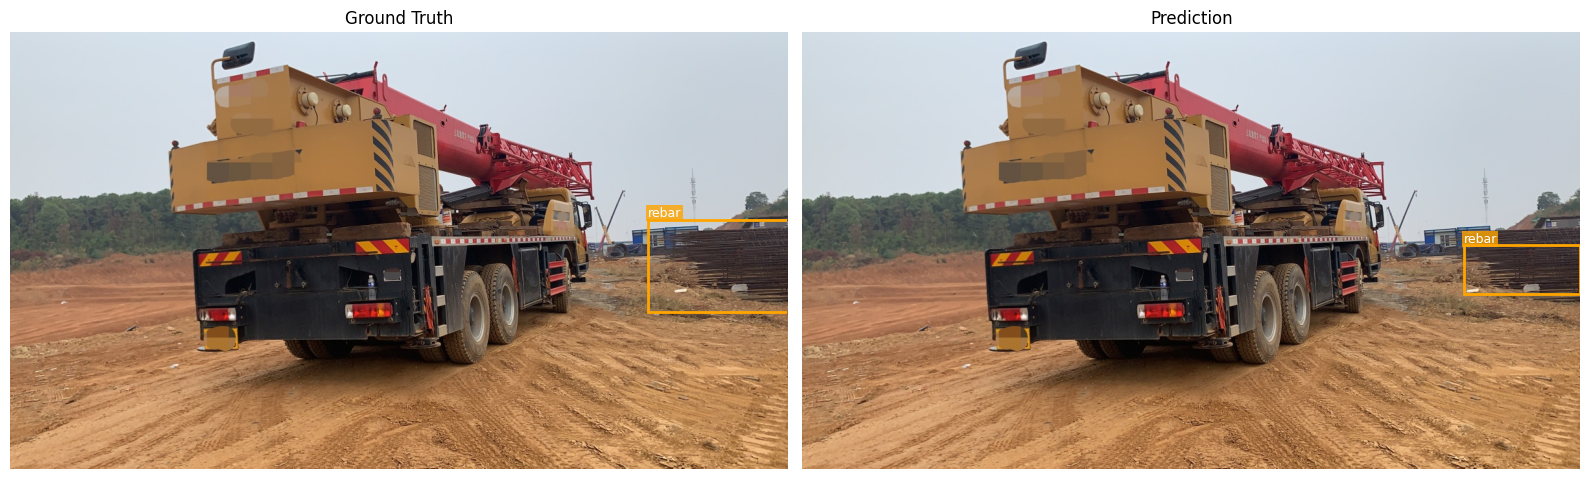

GT caption:   The rear view of a mobile crane.
Pred caption: A large yellow and red mobile crane is parked on a dirt road at a construction site. The ground is uneven with visible tire tracks. In the background, there are stacks of rebar and some buildings. No workers are clearly visible in the frame.

Sample 1 | image_id=0000002


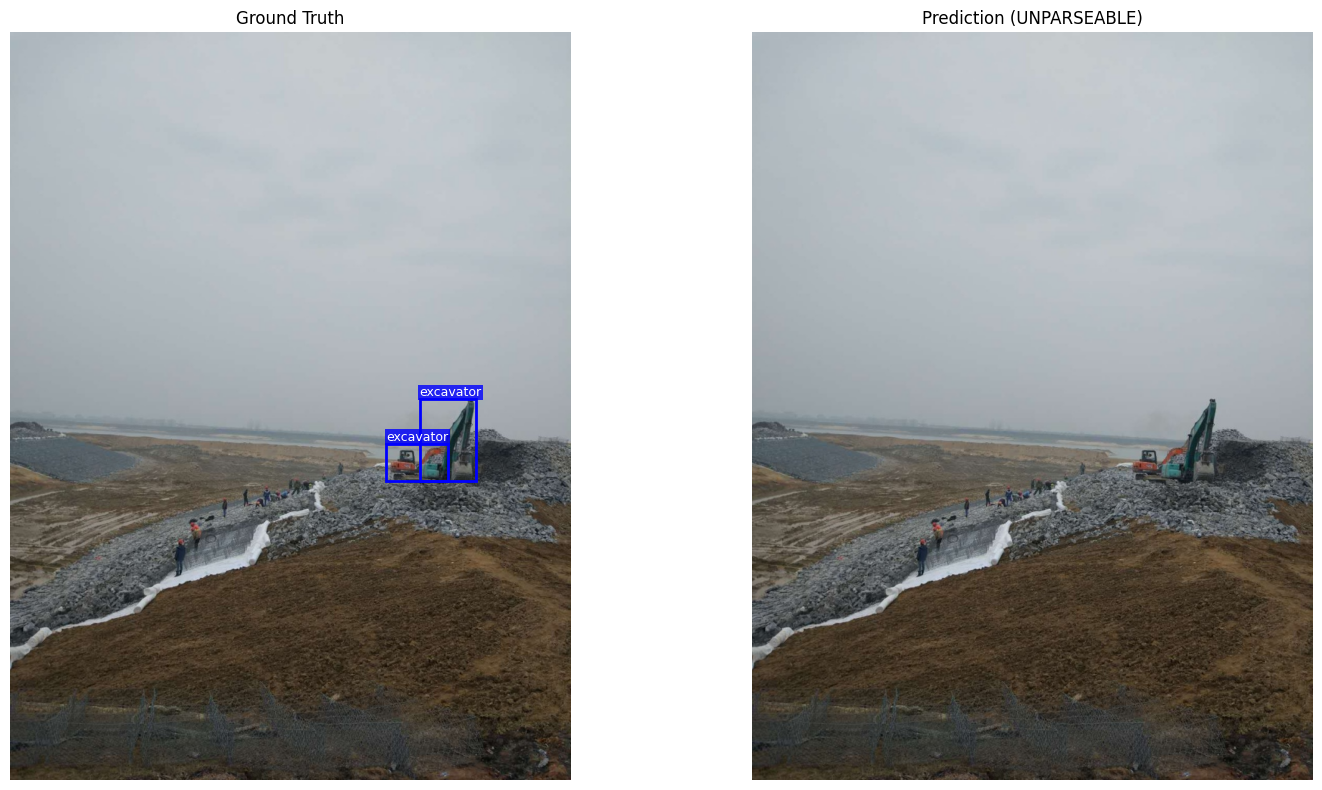

GT caption:   A stone pit. Fractured stones are covering the hill. There are two excavators on the right on top of the hill digging the pile of stones. There are more than 10 workers with red hard hats scattered on the slope. 
Pred caption: 

Sample 2 | image_id=0000005


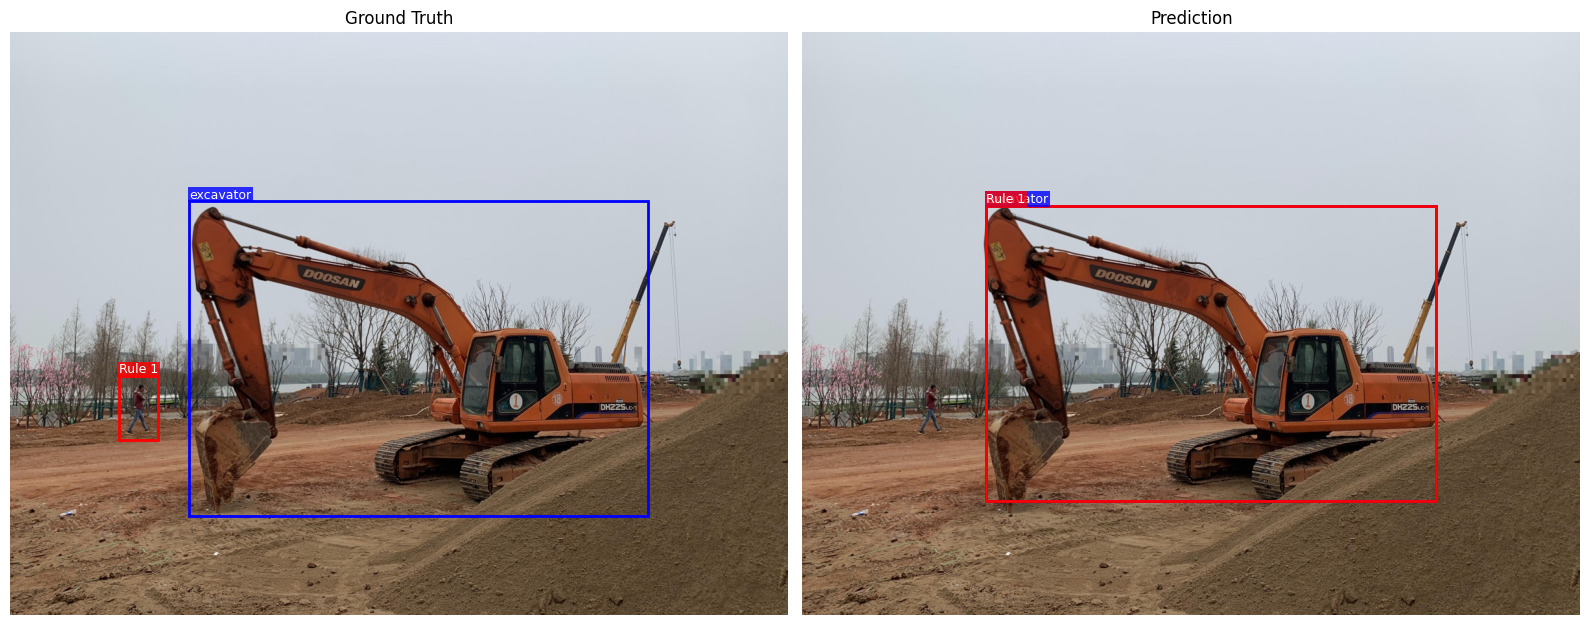

GT caption:   An excavator is in the center of the image. There is a person walking on the left, and a mobile crane on the right. The mobile crane is hidden by the excavator, but the boom and hook block is visible. A river is in the background.
Pred caption: A large orange Doosan DH225C-7 excavator is parked on a dirt site with its bucket lowered towards the ground. In the background, there's a person walking near some trees with pink blossoms. A crane arm extends into the distance. The sky is overcast, suggesting cloudy weather.


In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from data.box_utils import normalize_boxes, scale_1000_to_01

def draw_boxes_on_ax(ax, boxes_01, width, height, color, label):
    for box in boxes_01:
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin * width, ymin * height),
            (xmax - xmin) * width, (ymax - ymin) * height,
            linewidth=2, edgecolor=color, facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(xmin * width, ymin * height - 5, label, color="white", fontsize=9,
                 bbox=dict(facecolor=color, alpha=0.8, edgecolor="none", pad=1))


def compare_prediction_vs_gt(pil_image, gt_sample, pred_parsed):
    width, height = pil_image.size
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    for ax, title in zip(axes, ["Ground Truth", "Prediction"]):
        ax.imshow(pil_image)
        ax.axis("off")
        ax.set_title(title)
    gt_ax, pred_ax = axes

    for cls, color in [("excavator", "blue"), ("rebar", "orange"), ("worker_with_white_hard_hat", "green")]:
        draw_boxes_on_ax(gt_ax, normalize_boxes(gt_sample.get(cls, [])), width, height, color, cls)
    for i in range(1, 5):
        v = gt_sample.get(f"rule_{i}_violation")
        if v and v.get("bounding_box"):
            draw_boxes_on_ax(gt_ax, normalize_boxes(v["bounding_box"]), width, height, "red", f"Rule {i}")

    if pred_parsed:
        for cls, color in [("excavator", "blue"), ("rebar", "orange"), ("worker_with_white_hard_hat", "green")]:
            raw_boxes = sanitize_boxes(pred_parsed.get(cls, []))
            pred_boxes = [scale_1000_to_01(b) for b in normalize_boxes(raw_boxes)]
            draw_boxes_on_ax(pred_ax, pred_boxes, width, height, color, cls)

        for i in range(1, 5):
            v = pred_parsed.get(f"rule_{i}_violation")
            if isinstance(v, dict) and v.get("bounding_box"):
                raw_boxes = sanitize_boxes(v["bounding_box"])
                pred_boxes = [scale_1000_to_01(b) for b in normalize_boxes(raw_boxes)]
                draw_boxes_on_ax(pred_ax, pred_boxes, width, height, "red", f"Rule {i}")
    else:
        pred_ax.set_title("Prediction (UNPARSEABLE)")

    plt.tight_layout()
    plt.show()
    print("GT caption:  ", gt_sample.get("image_caption", ""))
    print("Pred caption:", (pred_parsed or {}).get("caption", ""))


# Show first 3 samples — re-pulls the PIL image from mini_test by index
N_SHOW = 3
for i in range(min(N_SHOW, len(mini_test))):
    print(f"\n{'='*70}\nSample {i} | image_id={mini_test[i]['image_id']}\n{'='*70}")
    compare_prediction_vs_gt(mini_test[i]["image"], mini_test[i], parsed_preds[i])